Newick representation:
((((((18:0.0008652321797613105,19:0.0008652321797613105)11:0.8805321193065905,10:0.8813973514863518)7:0.14071714045260064,((14:0.5691757141501868,15:0.5691757141501868)13:0.10503538450556227,(16:0.4409361481022245,17:0.4409361481022245)12:0.23327495055352454)6:0.3479033932832034)4:0.8733359825275455,(8:0.9553356258819772,9:0.9553356258819772)5:0.9401148485845208)3:0.202784472784443,2:2.098234947250941)1:0.08187493774851884)0:0.0;


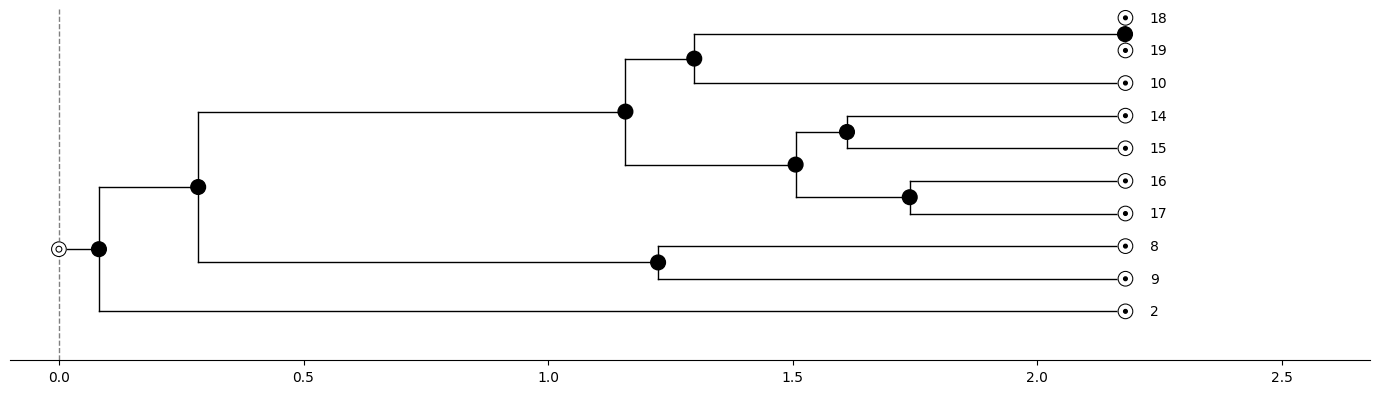

In [1]:
import asymmetree.treeevolve as te
from asymmetree.utils.phylogenetic_trees import to_newick
from asymmetree.visualization.tree_vis import visualize

# --- Generate a Yule tree ---
# n: number of extant species (leaves)
# model: 'yule' for the Yule (pure-birth) model
# birth_rate: speciation rate (default is 1.0 if not specified)
tree = te.species_tree_n(n=10, model="yule", birth_rate=1.0)

# --- Print in Newick format ---
newick_string = to_newick(tree)
print("Newick representation:")
print(newick_string)

# --- Visualize the tree ---
visualize(tree, save_as="yule_tree.pdf")

Newick representation of the BDP tree:
(((((((((((0:0.3543996737679028,3:0.3543996737679028)22:0.27547988061205364,(7:0.5799473674533194,8:0.5799473674533194)25:0.049932186926637034)27:0.41783241985157216,28:0.37086418588884584)31:0.22666475124690688,29:0.39279829093498053)39:0.16046676426371254,(((4:0.6087774252227324,9:0.6087774252227324)26:0.5371675657077338,32:0.02434519542091551)34:0.1217200810881871,33:0.13832364873613656)38:0.16717841772349473)41:0.20822829021783473,(((((2:0.17434504285704905,6:0.17434504285704905)18:1.0345004587032267,(14:0.2932503152984314,17:0.1537777221151615)20:0.9155951862618443)35:0.001857970129763853,(11:0.2492088565669212,12:0.2492088565669212)19:0.9614946151231183)36:0.006676451216001578,30:0.21181081836258953)37:0.13353113912475068,23:0.9616395100130142)40:0.29216071792919096)42:0.24221058480425794,((1:0.11270374429859681,5:0.11270374429859681)15:0.23274813190424037,(10:0.1301089778119766,13:0.1301089778119766)16:0.21534289839086057)21:1.5398304885614

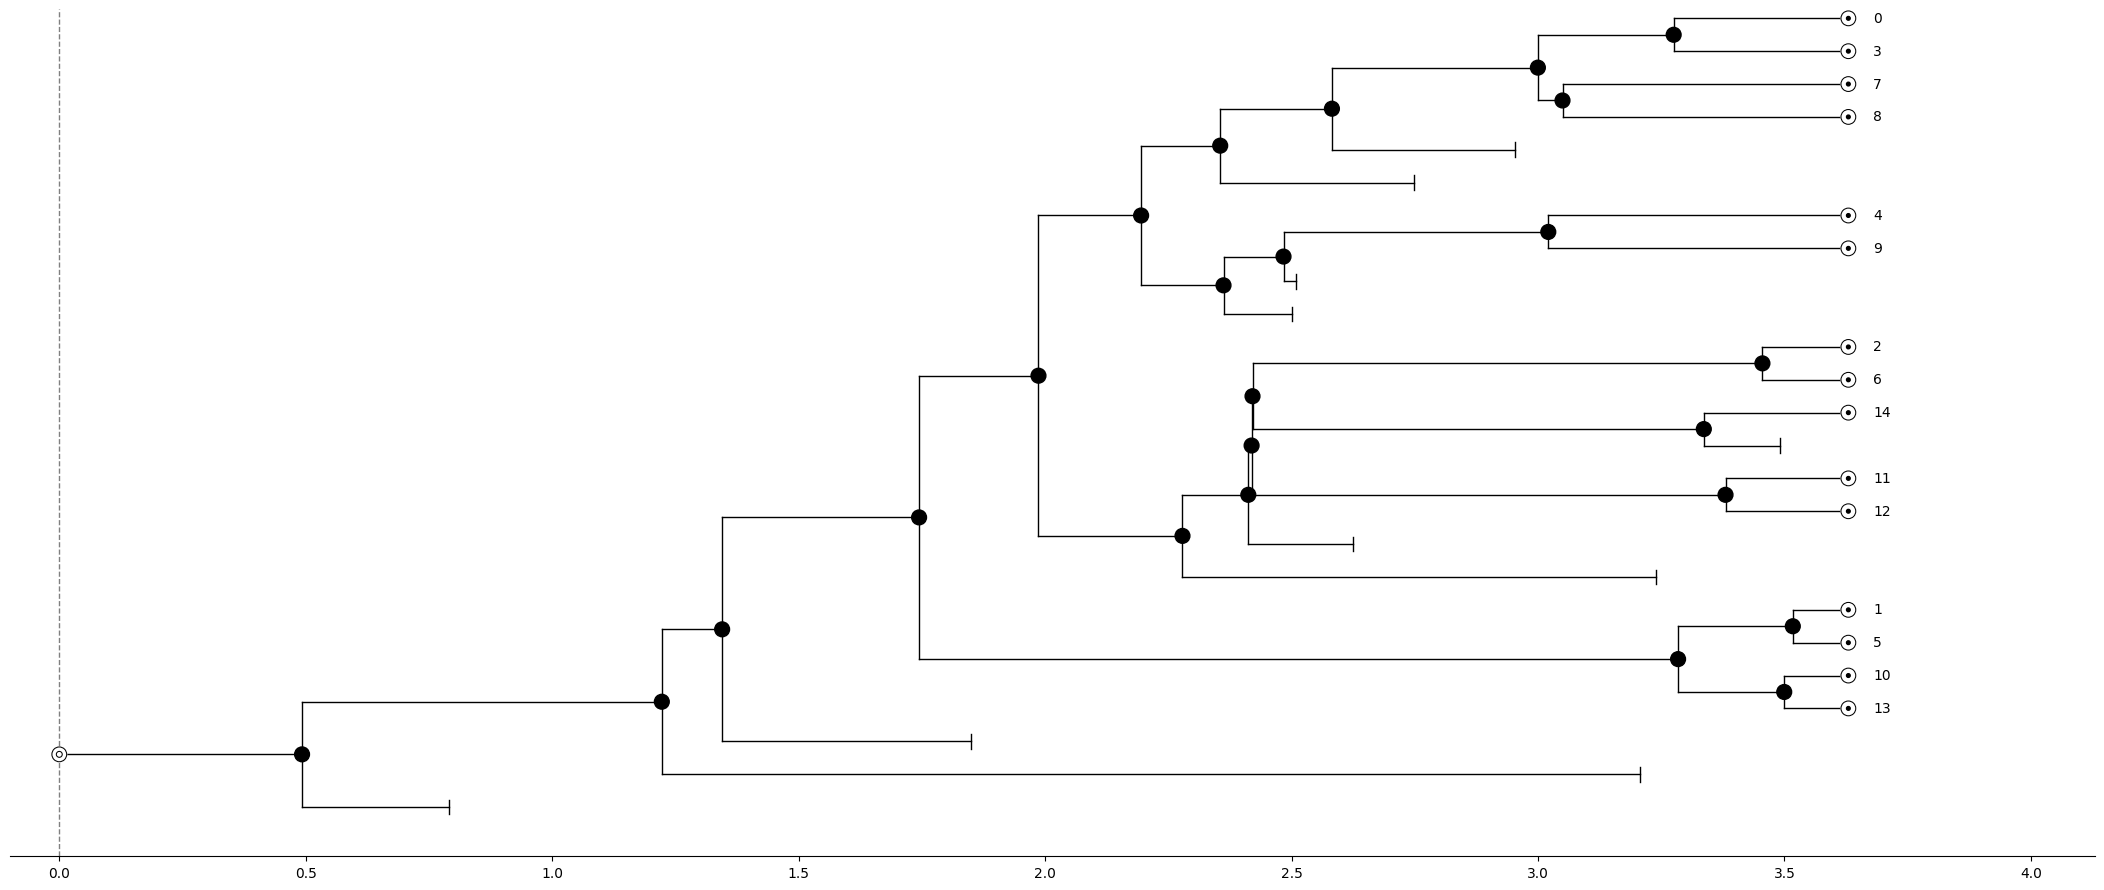

In [2]:
# --- Parameters for the Birth-Death process ---
n_leaves = 15               # number of extant species
birth = 1.0                 # speciation rate (lambda)
death = 0.6                 # extinction rate (mu)   (must be < birth for a realistic process)

# --- Generate the tree conditioned on 'n' extant tips ---
tree = te.species_tree_n(n=n_leaves, model="BDP", birth_rate=birth, death_rate=death)

# --- Print Newick string ---
newick_string = to_newick(tree)
print("Newick representation of the BDP tree:")
print(newick_string)

# --- Visualize the tree (saves a PDF) ---
visualize(tree, save_as="bdp_tree.pdf")

In [3]:
# --- Episodic BDP ---

# --- Define episodes ---
episodes = [
    (1.0, 0.3, 0.8, 0.0),   # Episode 1: from 0.0 to 0.3 time units ago
    (0.9, 0.4, 0.6, 0.3),   # Episode 2: from 0.3 to 0.6 time units ago
    (0.7, 0.5, 0.4, 0.6)    # Episode 3: from 0.6 time units ago and beyond
]
# The first episode MUST have time_stamp = 0.0

# --- Generate an EBDP tree conditioned on exactly 15 extant tips ---
tree = te.species_tree_n(
    n=15,
    model="EBDP",           # Episodic Birth-Death Process
    episodes=episodes,
    planted=True            # Adds a planted root edge (default)
)

# --- Print the tree in Newick format ---
print("EBDP tree in Newick format:")
print(to_newick(tree))

# --- Visualize ---
visualize(tree, save_as="ebdp_tree.pdf")

EBDP tree in Newick format:
(((((((((((((((((((((0:1.5673592160487273,144:0.20585875555965694)162:2.5100865938656023,((((48:0.9171042488376847,((48:0.45751115967277023,108:0.29126795206294076)127:0.25443000543503524,48:0.7119411651078055)140:0.20516308372987924)157:1.0214105824346336,223:0.04718272724553696)228:0.8774008104516766,242:0.6956237406145531)296:0.24089268062414027,48:3.056808322348135)317:0.42063748756619423)343:1.5946351356683452,((((((((1:0.15494004010656848,6:0.15494004010656848)21:0.6526616396205225,48:0.20760167972709098)111:1.0618612985787248,153:0.40210295309618016)183:1.0378385674324448,207:0.6203718241851264)256:0.24804893894153857,258:0.223792442169521)274:0.19036037872575173,((3:0.47709999395881636,42:0.002657017204480916)43:0.4046255672510663,115:0.04671736133371196)120:2.4639853021956686)289:0.5107528442500913,(((48:0.08008834700215428,48:0.08008834700215428)100:1.260186164419272,48:1.340274511421426)187:0.9166305511790154,247:0.04641011394524286)248:0.99955864